In [98]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

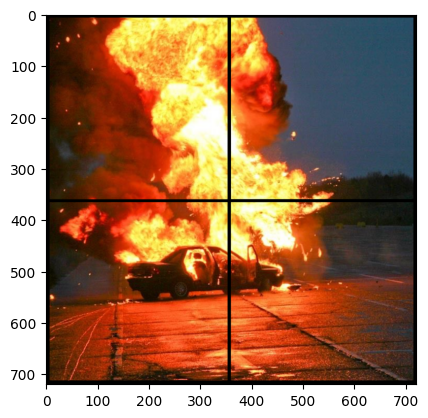

In [99]:
citra = plt.imread('Meledak.png')
plt.imshow(citra, cmap='gray')

slicing

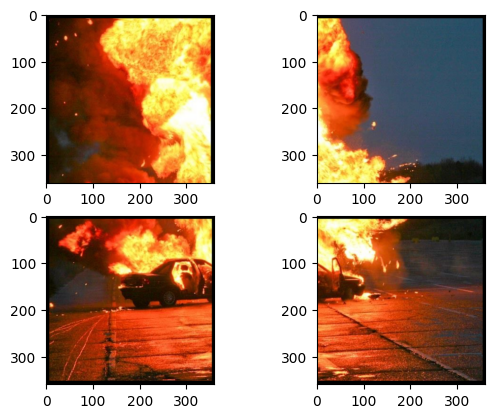

In [100]:
def slicing(gambar, a, b, mode='H'):
 return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]
h, w, c = citra.shape
atas = slicing(citra, 0, h//2, 'H')
bawah = slicing(citra, h//2, h, 'H')
ct1 = slicing(atas, 0, w//2, 'V')
ct2 = slicing(atas, w//2, w, 'V')
ct3 = slicing(bawah, 0, w//2, 'V')
ct4 = slicing(bawah, w//2, w, 'V')

plt.subplot(2,2,1)
plt.imshow(ct1, cmap='gray')

plt.subplot(2,2,2)
plt.imshow(ct2, cmap='gray')

plt.subplot(2,2,3)
plt.imshow(ct3, cmap='gray')

plt.subplot(2,2,4)
plt.imshow(ct4, cmap='gray')


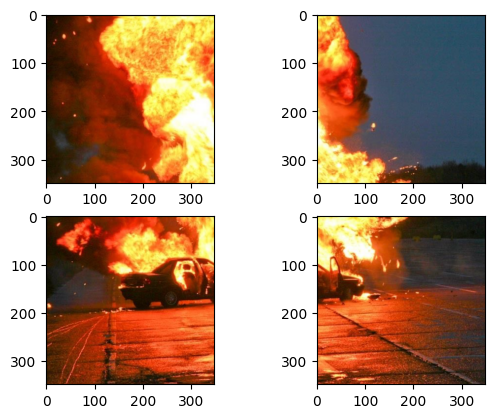

In [101]:
c1 = ct1[5:353, 5:353]
c2 = ct2[5:353, 5:353]
c3 = ct3[5:353, 5:353]
c4 = ct4[5:353, 5:353]

plt.subplot(2,2,1)
plt.imshow(c1, cmap='gray')

plt.subplot(2,2,2)
plt.imshow(c2, cmap='gray')

plt.subplot(2,2,3)
plt.imshow(c3, cmap='gray')

plt.subplot(2,2,4)
plt.imshow(c4, cmap='gray')


penggabungan

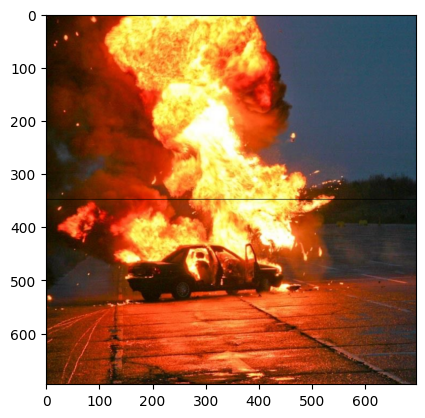

In [106]:
def merge_image(citra1, citra2, orientation='H'):

    if orientation == 'H':

        tinggi = max(citra1.shape[0], citra2.shape[0])
        lebar_total = citra1.shape[1] + citra2.shape[1]

        if len(citra1.shape) == 2:

            gabungan = np.zeros((tinggi, lebar_total),
                                dtype=citra1.dtype)
        else:

            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]),
                                dtype=citra1.dtype)
        gabungan[0:citra1.shape[0],
                 0:citra1.shape[1]] = citra1

        gabungan[0:citra2.shape[0],
                 citra1.shape[1]:citra1.shape[1] + citra2.shape[1]] = citra2
    else:

        tinggi_total = citra1.shape[0] + citra2.shape[0]
        lebar = max(citra1.shape[1], citra2.shape[1])
        if len(citra1.shape) == 2:

            gabungan = np.zeros((tinggi_total, lebar),
                                dtype=citra1.dtype)
        else:

            gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]),
                                dtype=citra1.dtype)
        gabungan[0:citra1.shape[0],
                 0:citra1.shape[1]] = citra1
        gabungan[citra1.shape[0]:citra1.shape[0] + citra2.shape[0],
                 0:citra2.shape[1]] = citra2

    return gabungan
merge1 = merge_image(c1, c2)
merge2 = merge_image(c3, c4)
merge = merge_image(merge1, merge2, 'Y')

plt.imshow(merge, cmap='gray')